# Colab setup

In [ ]:
import os
import platform
import torch
from pathlib import Path


#Check connection to Colab
print("Directory:", os.getcwd())
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

#Check repo in Colab
repo = Path("/content/routefinder")
print("RouteFinder exists:", repo.exists())
print("Git repository:", (repo / ".git").exists())
print("test.py exists:", (repo / "test.py").exists())

System: Linux
Directory: /content
CUDA: True
GPU: Tesla T4


In [ ]:
#If it is not there, clone to colab temporarily

!git clone --branch colab-compat https://github.com/PabloR0driguez/routefinder.git /content/routefinder
#Install environment
%cd /content/routefinder
!pip install -q uv
!uv sync --all-extras
#Get checkpoints
!uv run python scripts/download_hf.py
#Check checkpoints are there
root = Path("/content/routefinder")
checkpoints = sorted((root / "checkpoints").rglob("*.ckpt"))
datasets = sorted((root / "data").rglob("*.npz"))
print(f"Checkpoints found: {len(checkpoints)}")
for path in checkpoints:
    print(" ", path.relative_to(root))
print(f"\nDatasets found: {len(datasets)}")

Cloning into '/content/routefinder'...
remote: Enumerating objects: 1261, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 1261 (delta 74), reused 68 (delta 68), pack-reused 1175 (from 2)
Receiving objects: 100% (1261/1261), 420.66 MiB | 35.43 MiB/s, done.
Resolving deltas: 100% (677/677), done.


# Begin test

In [ ]:
from google.colab import files


In [10]:
#Run command with .venv 
#Load the 100 node RF transformer model
#Problem name: cvrp, vrptw, etc. or all. Here we use all
!uv run python test.py \
    --checkpoint checkpoints/100/rf-transformer.ckpt \
    --size 100 \
    --problem all \
    --batch_size 16 \
    --device cuda

Found 16 datasets on the following paths: ['data/cvrp/test/100.npz', 'data/ovrp/test/100.npz', 'data/vrpb/test/100.npz', 'data/vrpl/test/100.npz', 'data/ovrpb/test/100.npz', 'data/ovrpl/test/100.npz', 'data/vrpbl/test/100.npz', 'data/vrptw/test/100.npz', 'data/ovrpbl/test/100.npz', 'data/ovrptw/test/100.npz', 'data/vrpbtw/test/100.npz', 'data/vrpltw/test/100.npz', 'data/ovrpbtw/test/100.npz', 'data/ovrpltw/test/100.npz', 'data/vrpbltw/test/100.npz', 'data/ovrpbltw/test/100.npz']
Loading checkpoint from  checkpoints/100/rf-transformer.ckpt
/content/routefinder/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'env' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['env'])`.
/content/routefinder/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'policy' is an instance of `nn.Module` and is already saved during check

In [ ]:
#Download results

files.download(
    "/content/routefinder/results/main/100/rf-transformer.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
!uv run python test.py \
    --checkpoint checkpoints/100/rf-pomo.ckpt \
    --size 100 \
    --problem all \
    --batch_size 16 \
    --device cuda


files.download(
    "/content/routefinder/results/main/100/rf-pomo.pkl"
)



Found 16 datasets on the following paths: ['data/cvrp/test/100.npz', 'data/ovrp/test/100.npz', 'data/vrpb/test/100.npz', 'data/vrpl/test/100.npz', 'data/ovrpb/test/100.npz', 'data/ovrpl/test/100.npz', 'data/vrpbl/test/100.npz', 'data/vrptw/test/100.npz', 'data/ovrpbl/test/100.npz', 'data/ovrptw/test/100.npz', 'data/vrpbtw/test/100.npz', 'data/vrpltw/test/100.npz', 'data/ovrpbtw/test/100.npz', 'data/ovrpltw/test/100.npz', 'data/vrpbltw/test/100.npz', 'data/ovrpbltw/test/100.npz']
Loading checkpoint from  checkpoints/100/rf-pomo.ckpt
/content/routefinder/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'env' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['env'])`.
/content/routefinder/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'policy' is an instance of `nn.Module` and is already saved during checkpointin

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
!uv run python test.py \
    --checkpoint checkpoints/100/rf-moe.ckpt \
    --size 100 \
    --problem all \
    --batch_size 16 \
    --device cuda

from google.colab import files

files.download(
    "/content/routefinder/results/main/100/rf-moe.pkl"
)

Found 16 datasets on the following paths: ['data/cvrp/test/100.npz', 'data/ovrp/test/100.npz', 'data/vrpb/test/100.npz', 'data/vrpl/test/100.npz', 'data/ovrpb/test/100.npz', 'data/ovrpl/test/100.npz', 'data/vrpbl/test/100.npz', 'data/vrptw/test/100.npz', 'data/ovrpbl/test/100.npz', 'data/ovrptw/test/100.npz', 'data/vrpbtw/test/100.npz', 'data/vrpltw/test/100.npz', 'data/ovrpbtw/test/100.npz', 'data/ovrpltw/test/100.npz', 'data/vrpbltw/test/100.npz', 'data/ovrpbltw/test/100.npz']
Loading checkpoint from  checkpoints/100/rf-moe.ckpt
/content/routefinder/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'env' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['env'])`.
/content/routefinder/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'policy' is an instance of `nn.Module` and is already saved during checkpointing

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Local testing

In [4]:
%cd "C:\Users\josep\Downloads\Important Uni Stuff\WS26\Code_repo\routefinder"
!git checkout colab-compat
!git pull
!pip install -q uv
!uv sync --all-extras
!uv run python scripts/download_hf.py

from pathlib import Path
root = Path(r"C:\Users\josep\Downloads\Important Uni Stuff\WS26\Code_repo\routefinder")
checkpoints = sorted((root / "checkpoints").rglob("*.ckpt"))
datasets = sorted((root / "data").rglob("*.npz"))
print(f"Checkpoints found: {len(checkpoints)}")
for path in checkpoints:
    print(" ", path.relative_to(root))
print(f"\nDatasets found: {len(datasets)}")

C:\Users\josep\Downloads\Important Uni Stuff\WS26\Code_repo\routefinder
M	routefinder/data/generate.py
M	routefinder/envs/mtvrp/env.py
M	routefinder/envs/mtvrp/generator.py
Your branch is up to date with 'origin/colab-compat'.


Already on 'colab-compat'


Already up to date.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: C:\Users\josep\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
Resolved 166 packages in 2ms
Checked 129 packages in 29ms


Checkpoints found: 15
  checkpoints\100\mtpomo.ckpt
  checkpoints\100\mvmoe.ckpt
  checkpoints\100\pomo\pomo-cvrp.ckpt
  checkpoints\100\pomo\pomo-ovrp.ckpt
  checkpoints\100\pomo\pomo-vrpb.ckpt
  checkpoints\100\pomo\pomo-vrpl.ckpt
  checkpoints\100\pomo\pomo-vrptw.ckpt
  checkpoints\100\rf-moe.ckpt
  checkpoints\100\rf-pomo.ckpt
  checkpoints\100\rf-transformer.ckpt
  checkpoints\50\mtpomo.ckpt
  checkpoints\50\mvmoe.ckpt
  checkpoints\50\rf-moe.ckpt
  checkpoints\50\rf-pomo.ckpt
  checkpoints\50\rf-transformer.ckpt

Datasets found: 576



Fetching 576 files: 100%|██████████| 576/576 [00:02<00:00, 281.57it/s]

Fetching 15 files: 100%|██████████| 15/15 [00:00<00:00, 226.70it/s]


In [2]:


!uv run python test.py \
    --checkpoint checkpoints/100/rf-transformer.ckpt \
    --size 100 \
    --problem all \
    --batch_size 16 \
    --device cuda

[WinError 3] The system cannot find the path specified: 'path/to/your/routefinder'
c:\Users\josep\Downloads\Important Uni Stuff\WS26\Code_repo\routefinder


C:\Users\josep\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\magics\osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})


M	routefinder/data/generate.py
M	routefinder/envs/mtvrp/env.py
Your branch is up to date with 'origin/colab-compat'.


Already on 'colab-compat'


Already up to date.


...

Checkpoints found: 0

Datasets found: 0



Fetching 576 files: 100%|██████████| 576/576 [00:03<00:00, 188.31it/s]

Fetching 15 files: 100%|██████████| 15/15 [00:00<00:00, 89.19it/s]


^C


Found 16 datasets on the following paths: ['data\\cvrp\\test\\100.npz', 'data\\ovrp\\test\\100.npz', 'data\\vrpb\\test\\100.npz', 'data\\vrpl\\test\\100.npz', 'data\\ovrpb\\test\\100.npz', 'data\\ovrpl\\test\\100.npz', 'data\\vrpbl\\test\\100.npz', 'data\\vrptw\\test\\100.npz', 'data\\ovrpbl\\test\\100.npz', 'data\\ovrptw\\test\\100.npz', 'data\\vrpbtw\\test\\100.npz', 'data\\vrpltw\\test\\100.npz', 'data\\ovrpbtw\\test\\100.npz', 'data\\ovrpltw\\test\\100.npz', 'data\\vrpbltw\\test\\100.npz', 'data\\ovrpbltw\\test\\100.npz']
Loading checkpoint from  checkpoints/100/rf-transformer.ckpt
Loading data\cvrp\test\100.npz


c:\Users\josep\Downloads\Important Uni Stuff\WS26\Code_repo\routefinder\.venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'env' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['env'])`.
c:\Users\josep\Downloads\Important Uni Stuff\WS26\Code_repo\routefinder\.venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'policy' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['policy'])`.

  0%|          | 0/16 [17:29<?, ?it/s]
Traceback (most recent call last):
  File "c:\Users\josep\Downloads\Important Uni Stuff\WS26\Code_repo\routefinder\test.py", line 226, in <module>
    dataset_name = dataset.split("/")[-3].split(".")[0].upper()
                   ~~~~~~~~~~~~~~~~~~^^^^
IndexError: list index out of range


# Local testing multi

In [14]:
%cd "C:\Users\josep\Downloads\Important Uni Stuff\WS26\Code_repo\routefinder"
!uv run python test_diverse_vehicles.py \
    --checkpoint checkpoints/100/rf-transformer.ckpt \
    --size 100 \
    --problem cvrp \
    --batch_size 50 \
    --num_instances 100 \
    --fleet_size 50 \
    --min_speed 0.5 \
    --max_speed 1 \
    --min_capacity_factor 0.5 \
    --max_capacity_factor 1 \
    --device cuda

C:\Users\josep\Downloads\Important Uni Stuff\WS26\Code_repo\routefinder
Loading checkpoint from  checkpoints/100/rf-transformer.ckpt
[DEBUG] Reshaped reward: torch.Size([50, 1, 1])
[DEBUG] Reshaped reward: torch.Size([50, 8, 100])
[DEBUG] Augmentation selection
 reward_: torch.Size([50, 8])
  max_idxs: torch.Size([50])
[DEBUG] Reshaped reward: torch.Size([50, 1, 1])
[DEBUG] Reshaped reward: torch.Size([50, 8, 100])
[DEBUG] Augmentation selection
 reward_: torch.Size([50, 8])
  max_idxs: torch.Size([50])
MULTI_FLEET_CVRP | Cost: 18.960 | Inference time: 119.628 s


c:\Users\josep\Downloads\Important Uni Stuff\WS26\Code_repo\routefinder\.venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'env' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['env'])`.
c:\Users\josep\Downloads\Important Uni Stuff\WS26\Code_repo\routefinder\.venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'policy' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['policy'])`.


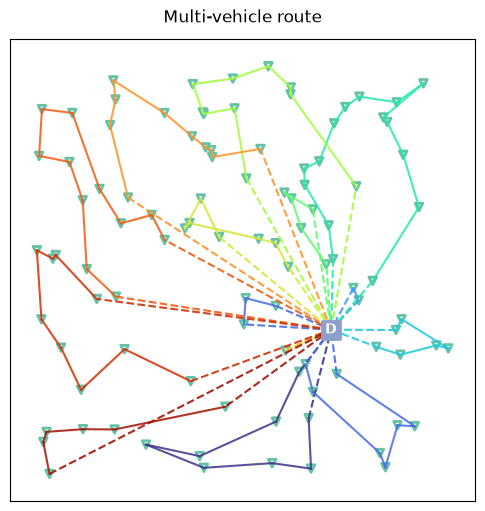

In [15]:
from IPython.display import Image, display

display(Image(filename="multivehicle_route.png"))

In [ ]:
%cd "C:\Users\josep\Downloads\Important Uni Stuff\WS26\Code_repo\routefinder"

!uv run python test_diverse_vehicles.py \
    --checkpoint checkpoints/100/rf-transformer.ckpt \
    --size 100 \
    --problem all \
    --batch_size 50 \
    --num_instances 100 \
    --fleet_size 50 \
    --min_speed 0.5 \
    --max_speed 1 \
    --min_capacity_factor 0.5 \
    --max_capacity_factor 1 \
    --device cuda

C:\Users\josep\Downloads\Important Uni Stuff\WS26\Code_repo\routefinder


C:\Users\josep\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


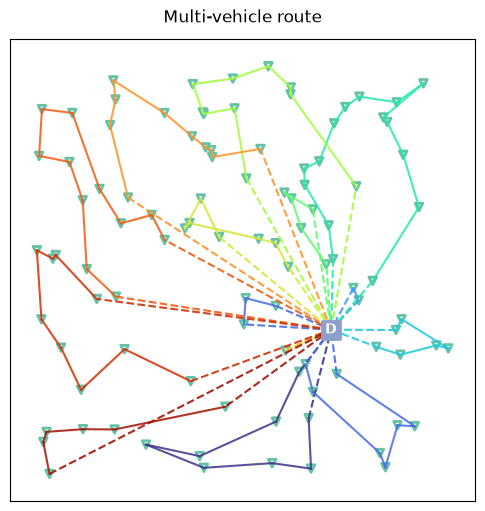

In [2]:
from IPython.display import Image, display

display(Image(filename="multivehicle_route.png"))

## Single vehicle

In [ ]:
%cd "C:\Users\josep\Downloads\Important Uni Stuff\WS26\Code_repo\routefinder"
!uv run python test_diverse_vehicles.py \
    --checkpoint checkpoints/100/rf-transformer.ckpt \
    --size 100 \
    --problem cvrp \
    --batch_size 50 \
    --num_instances 100 \
    --fleet_size 1 \
    --min_speed 1.0 --max_speed 1.0 \
    --min_capacity_factor 1.0 --max_capacity_factor 1.0 \
    --device cuda

C:\Users\josep\Downloads\Important Uni Stuff\WS26\Code_repo\routefinder
Loading checkpoint from  checkpoints/100/rf-transformer.ckpt
[DEBUG] Reshaped reward: torch.Size([50, 1, 1])
[DEBUG] Reshaped reward: torch.Size([50, 8, 100])
[DEBUG] Augmentation selection
 reward_: torch.Size([50, 8])
  max_idxs: torch.Size([50])
[DEBUG] Reshaped reward: torch.Size([50, 1, 1])
[DEBUG] Reshaped reward: torch.Size([50, 8, 100])
[DEBUG] Augmentation selection
 reward_: torch.Size([50, 8])
  max_idxs: torch.Size([50])
MULTI_FLEET_CVRP | Cost: 15.762 | Inference time: 98.314 s


c:\Users\josep\Downloads\Important Uni Stuff\WS26\Code_repo\routefinder\.venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'env' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['env'])`.
c:\Users\josep\Downloads\Important Uni Stuff\WS26\Code_repo\routefinder\.venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'policy' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['policy'])`.
